# Reusable FScanpy prediction plots

This example uses the bundled full-sequence data and the package plotting functions added in version 1.0.1. Full and local figures retain two red heatmaps above black probability bars. Reference positions are marked independently in green. Existing prediction tables can be reused without repeating model inference.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import display
from FScanpy import plot_prf_prediction, plot_prediction_results, plot_prediction_regions
from FScanpy.data import get_test_data_path

torch.set_num_threads(1)
data = pd.read_csv(get_test_data_path("predict_sample_examples.csv"))
row = data.iloc[1]
sequence = str(row.Full_Sequence)
reference = int(row.reference_codon_start_0based)

## Predict once and draw the full sequence

`window_size=3` scans every three nucleotides. The short and long display thresholds are both 0.2. Optional panel ratios provide the tutorial's thick heatmaps without accessing Matplotlib internals.

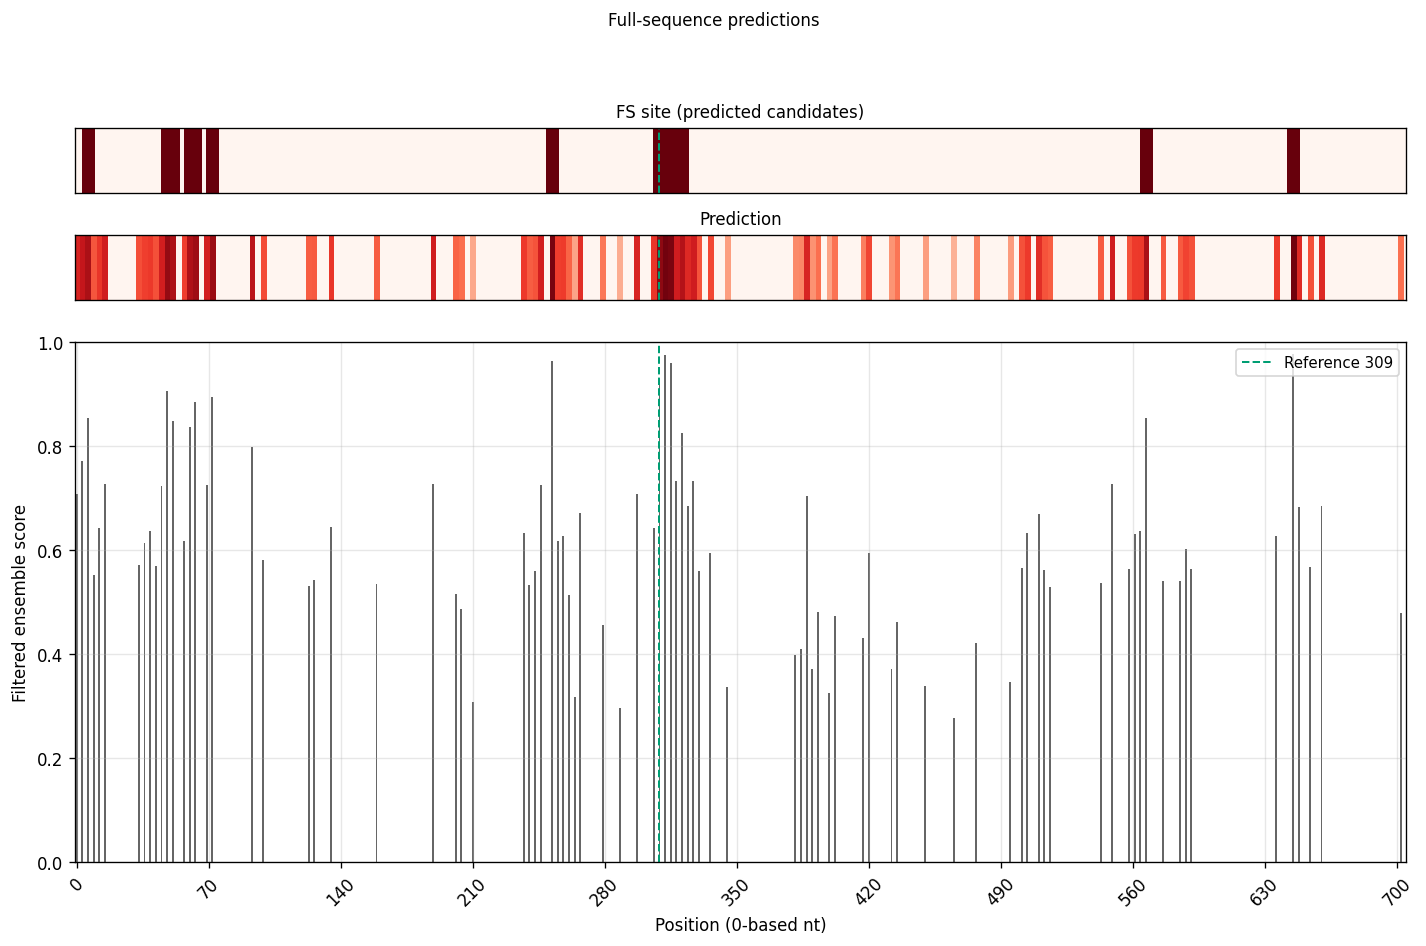

In [2]:
results, full_figure = plot_prf_prediction(
    sequence, window_size=3, short_threshold=0.2, long_threshold=0.2,
    ensemble_weight=0.6, reference_positions=[reference],
    heatmap_ratios=(0.35, 0.35, 2.8), title="Full-sequence predictions", dpi=120,
)
plt.show()

## Compare the reference and a competing region

Choose a high-scoring region away from the reference, then compare equal-sized local views. The summary counts scanned output rows; nearby scores share overlapping model windows.

,region,center,high_score_positions,scanned_positions,local_max
0,Reference,309,6,11,0.975485
1,Competitor,645,1,11,0.976088


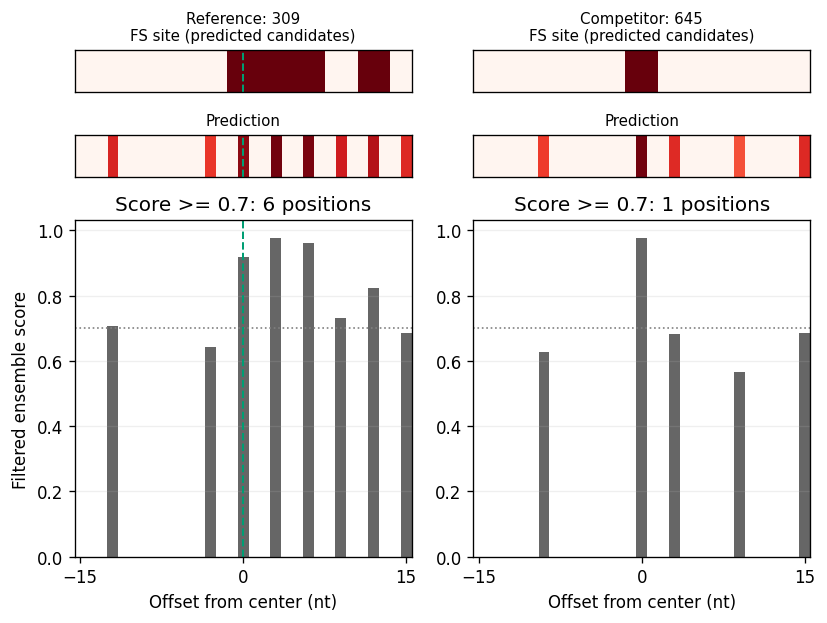

In [3]:
visible = results.Ensemble_Probability.where(
    (results.Short_Probability >= 0.2) & (results.Long_Probability >= 0.2), 0)
remote = (results.Position-reference).abs() > 30
competitor = int(results.loc[visible[remote].idxmax(), "Position"])
summary, local_figure = plot_prediction_regions(
    results, [("Reference", reference), ("Competitor", competitor)],
    radius=15, reference_positions=[reference],
)
display(summary)
plt.show()

## Replot the saved table

A different display threshold can be applied without reloading models or recalculating predictions. This only filters the stored scores; scores skipped by the original inference gate would require new inference.

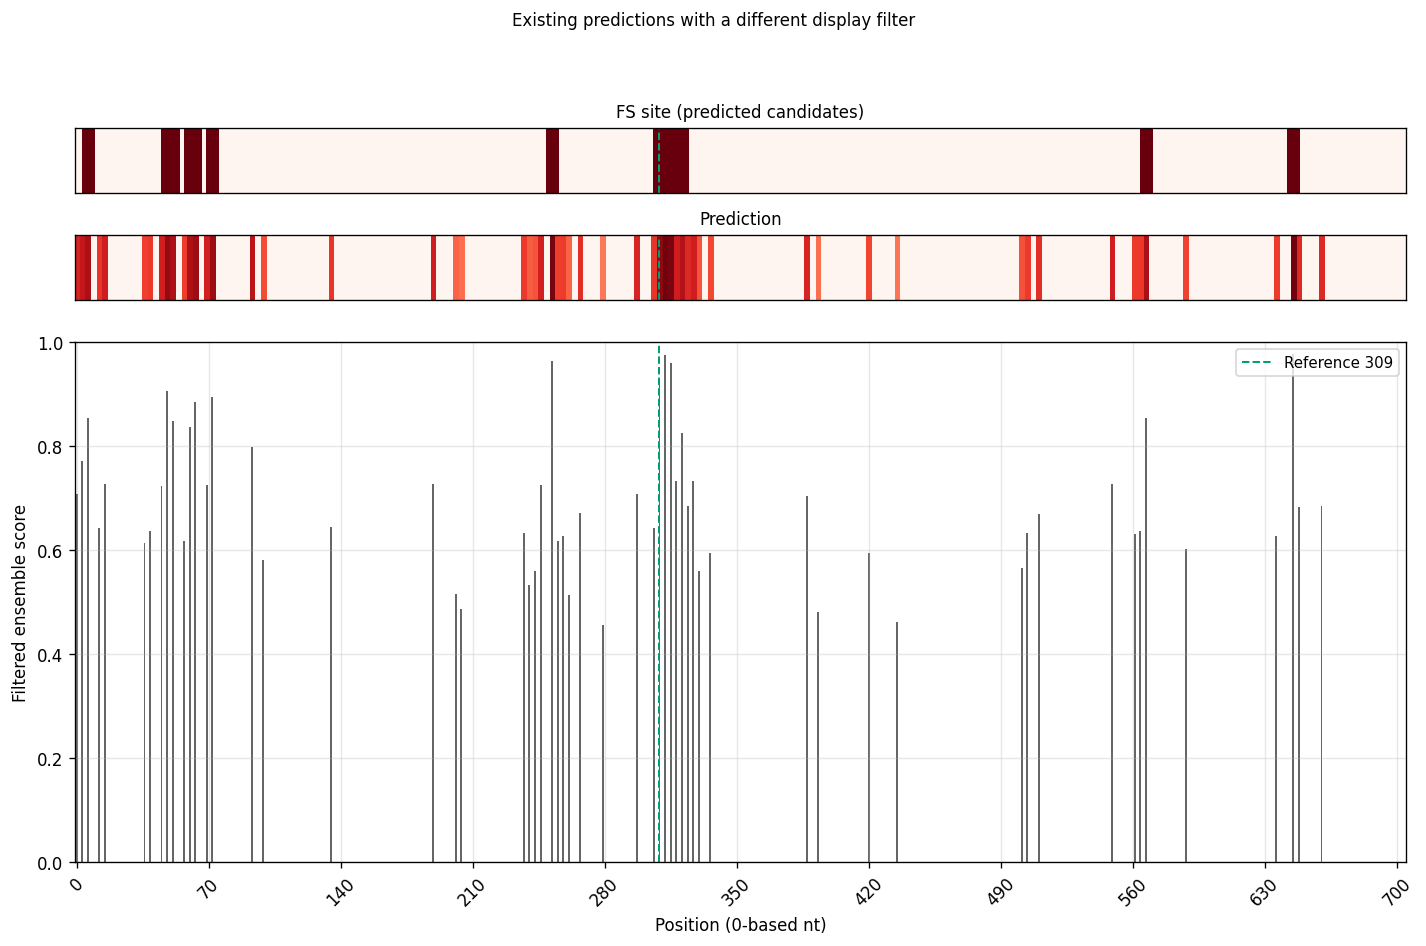

In [4]:
_, reused_figure = plot_prediction_results(
    results, sequence_length=len(sequence), short_threshold=0.3, long_threshold=0.3,
    reference_positions=[reference], heatmap_ratios=(0.35, 0.35, 2.8),
    title="Existing predictions with a different display filter", dpi=120,
)
plt.show()